# INCENT quickstart on synthetic data

This notebook builds two synthetic spatial-transcriptomics slices that share a
**known ground-truth correspondence** (the second slice is a rotated, jittered
copy of the first), runs `incent.pairwise_align`, and reports recovery
metrics. It is fully self-contained — no downloads required — and runs in
under a minute on CPU.

Use this as the canonical "does everything install correctly?" smoke test
before moving on to real datasets (see `02_dlpfc.ipynb`).

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np

import incent

print(f"INCENT version: {incent.__version__}")

INCENT version: 0.1.0


## 1. Build the slice pair

Source slice has 200 cells in four spatial blobs (one per cell type). Target
slice is the same cells, **rotated by 35°** with small per-cell jitter and a
tiny gene-expression noise. Cell-type labels are preserved.

In [2]:
rng = np.random.default_rng(0)
n_cells, n_genes = 200, 60
cell_types = np.array(["Excitatory", "Inhibitory", "Astrocyte", "Microglia"])

type_centers = np.array([[-3.0, -3.0], [3.0, -3.0], [-3.0, 3.0], [3.0, 3.0]])
type_assign = rng.integers(0, 4, size=n_cells)
coords_A = type_centers[type_assign] + rng.normal(scale=0.6, size=(n_cells, 2))
labels_A = cell_types[type_assign]

type_means = rng.normal(scale=2.0, size=(4, n_genes))
XA = type_means[type_assign] + rng.normal(scale=0.5, size=(n_cells, n_genes))

theta = np.deg2rad(35.0)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
coords_B = coords_A @ R.T + rng.normal(scale=0.15, size=(n_cells, 2))
labels_B = labels_A.copy()
XB = XA + rng.normal(scale=0.2, size=(n_cells, n_genes))

A = ad.AnnData(X=XA.astype(np.float32))
A.obsm["spatial"] = coords_A.astype(np.float32)
A.obs["cell_type_annot"] = labels_A
B = ad.AnnData(X=XB.astype(np.float32))
B.obsm["spatial"] = coords_B.astype(np.float32)
B.obs["cell_type_annot"] = labels_B

truth = np.arange(n_cells)  # cell i in A corresponds to cell i in B
print(A, B, sep="\n\n")

AnnData object with n_obs × n_vars = 200 × 60
    obs: 'cell_type_annot'
    obsm: 'spatial'

AnnData object with n_obs × n_vars = 200 × 60
    obs: 'cell_type_annot'
    obsm: 'spatial'


## 2. Run INCENT

Default hyperparameters work well on this clean toy. On real data you will
typically tune `alpha` and `gamma` (see the README cheat-sheet).

In [3]:
pi = incent.pairwise_align(
    A, B,
    alpha=0.5, beta=0.3, gamma=0.5,
    use_gpu=False, gpu_verbose=False,
    unbalanced=False, verbose=False,
)

print(f"pi.shape = {pi.shape}, pi.sum() = {pi.sum():.4f}")

Calculating spatial distance between cells in slice A and slice B
Calculating cosine distance between gene expression profiles of slice A and slice B
Calculating cost matrix


  0%|                                                   | 0/200 [00:00<?, ?it/s]

100%|███████████████████████████████████████| 200/200 [00:00<00:00, 2577.53it/s]

Finished calculating cost matrix
pi.shape = (200, 200), pi.sum() = 1.0000


## 3. Quantify recovery

- **Top-1 cell-correspondence**: fraction of source cells whose `argmax`
  partner in `pi` is the true partner. Random would be `1/n = 0.5%`.
- **Label-transfer accuracy**: fraction of source cells whose `argmax`
  partner in `pi` carries the same cell-type label.

In [4]:
pred = pi.argmax(axis=1)
top1 = float((pred == truth).mean())
label_acc = float((B.obs["cell_type_annot"].to_numpy()[pred]
                   == A.obs["cell_type_annot"].to_numpy()).mean())

print(f"top-1 cell-correspondence:  {top1:.2%}")
print(f"label-transfer accuracy:    {label_acc:.2%}")

top-1 cell-correspondence:  72.50%
label-transfer accuracy:    100.00%


In [5]:
metrics = incent.calculate_performance_metrics(pi, sliceA=A, sliceB=B, use_gpu=False)
metrics

Calculating cost matrix


  0%|                                                   | 0/200 [00:00<?, ?it/s]

/home/ubuntu/.pyenv/versions/3.12.8/lib/python3.12/site-packages/ot/backend.py:1212: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(a)


100%|███████████████████████████████████████| 200/200 [00:00<00:00, 3376.50it/s]

Finished calculating cost matrix
Calculating cosine distance between gene expression profiles of slice A and slice B

                           ALIGNMENT QUALITY METRICS
 Metric                                  Initial      Final        Improvement 
--------------------------------------------------------------------------------
 Neighborhood Dissimilarity (JSD)        nan          nan                 nan%
 Gene Expression Dissimilarity (Cosine)  0.753265     0.022586          97.00%
 Cell-type Correspondence (%)            25.39        100.00           293.78%



{'initial_obj_neighbor': np.float64(nan),
 'final_obj_neighbor': np.float64(nan),
 'initial_obj_gene': np.float64(0.7532651447653771),
 'final_obj_gene': np.float64(0.0225862566548714),
 'initial_cell_type_match': np.float64(0.25394999999999995),
 'final_cell_type_match': np.float64(0.9999999999999926)}

## 4. Visualize the alignment

`incent.visualize.stack_slices_pairwise` runs a Procrustes registration
driven by `pi`. After it, the two slices should overlap.

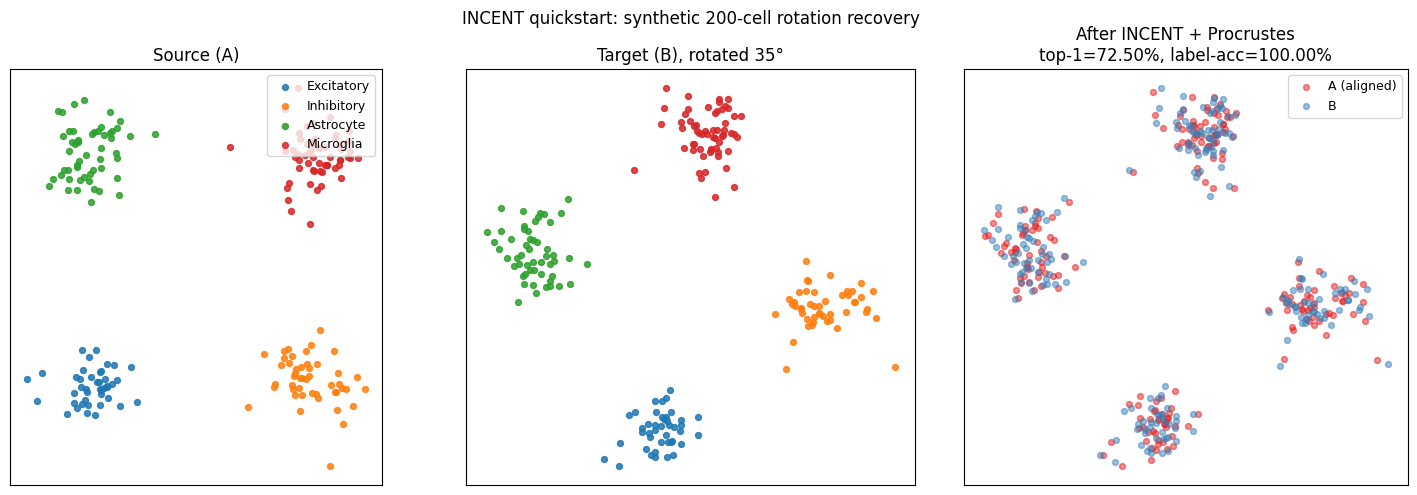

In [6]:
aligned = incent.visualize.stack_slices_pairwise([A, B], [pi])
coords_A_aligned = aligned[0].obsm["spatial"]
coords_B_aligned = aligned[1].obsm["spatial"]

type_to_color = {"Excitatory": "#1f77b4", "Inhibitory": "#ff7f0e",
                 "Astrocyte": "#2ca02c", "Microglia": "#d62728"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, slice_, title in [
    (axes[0], A, "Source (A)"),
    (axes[1], B, "Target (B), rotated 35°"),
]:
    for ct, color in type_to_color.items():
        mask = slice_.obs["cell_type_annot"].to_numpy() == ct
        ax.scatter(slice_.obsm["spatial"][mask, 0],
                   slice_.obsm["spatial"][mask, 1],
                   s=18, alpha=0.85, c=color, label=ct)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])

ax = axes[2]
ax.scatter(coords_A_aligned[:, 0], coords_A_aligned[:, 1], s=18, alpha=0.5,
           c="#e41a1c", label="A (aligned)")
ax.scatter(coords_B_aligned[:, 0], coords_B_aligned[:, 1], s=18, alpha=0.5,
           c="#377eb8", label="B")
ax.set_title(f"After INCENT + Procrustes\ntop-1={top1:.2%}, label-acc={label_acc:.2%}")
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper right", fontsize=9)
axes[0].legend(loc="upper right", fontsize=9)
fig.suptitle("INCENT quickstart: synthetic 200-cell rotation recovery")
fig.tight_layout()

## What to try next

- Vary `alpha` between 0.1 and 0.9 to see how much weight on spatial vs.
  feature cost the recovery tolerates.
- Set `unbalanced=True` and add 50 "extra" cells in slice B that are not in
  slice A. INCENT should leave them unmatched.
- Increase `n_cells` to 5000 and switch to
  `incent.hierarchical_pairwise_align` to see the coarse-to-fine schedule
  in action.
- Move on to `02_dlpfc.ipynb` for a real Visium DLPFC alignment.